# ATiG 2026: LT-FH exercise

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bvilhjal/ATIG_2026/blob/main/teaching_days/2026-09-24/LTFH/LTFH_exercise_answers.ipynb)

Worked answers.

In this exercise you simulate a disease register in which the true genetic liability of
every person is known, describe the data, score everyone with LT-FH++ using the Python
package [ltpred](https://github.com/bvilhjal/ltpred), and check the scores against the
truth.

Open the notebook in Colab and run the cells in order. All code is complete in this
answer sheet. The student notebook has five marked cells to complete.
The point is to interpret what you see, so write your answers down. Work in pairs. Parts 0, A and B are
for the class (about an hour); parts C to E are homework.

Background: under the liability-threshold model a person is diagnosed when their
liability, a genetic part `g` plus an environmental part, crosses a threshold. In
LT-FH++ ([Pedersen et al. 2022](https://doi.org/10.1016/j.ajhg.2022.01.009)) the
threshold depends on age and sex, and the score is the expected value of `g` given the
diagnoses and ages of a person and their relatives. See the slides from 22 September.

Python you will need: `x[mask]` keeps the entries of `x` where `mask` is True; `a & b` and
`~a` combine and negate True/False arrays; `.mean()` of a True/False array is the share of
True values; `[f(x) for x in xs]` applies `f` to each element of a list.

## Setup

In [ ]:
%pip install -q git+https://github.com/bvilhjal/ltpred@v0.7.1     # installs ltpred (about 30 s)

In [1]:
import numpy as np
from scipy.stats import norm, rankdata
import matplotlib.pyplot as plt

import ltpred
from ltpred import (simulate_pedigree, simulate_register_liabilities, estimate_liabilities,
                    kaplan_meier_cip)
from dataclasses import replace
from collections import Counter
print("ltpred", ltpred.__version__)


def corr(x, y):
    """Pearson correlation of two arrays."""
    return np.corrcoef(x, y)[0, 1]


def auc(score, case):
    """AUC: the chance that a random case scores above a random non-case.

    Computed from ranks (the Mann-Whitney statistic); `case` is a boolean array."""
    r = rankdata(score)
    n1, n0 = case.sum(), (~case).sum()
    return (r[case].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)

ltpred 0.7.2


## Part 0: The data

The next cell simulates three generations of families. The disease affects 12% of men
and 8% of women by old age, h² = 0.5, and everyone is followed to age 70. Fathers are men
and mothers women; the others are given a random sex. `reg` holds the pedigree
(`reg.ids`, `reg.father`, `reg.mother`), whether each person was diagnosed by 70
(`reg.status`), the age at diagnosis (`reg.onset`), the age at the end of follow-up
(`reg.age`), the birth year (`reg.birth_time`) and the true genetic liability, stored as
`g`.

In [2]:
H2 = 0.5                                        # true liability-scale heritability
AGES = np.arange(0, 121.0)                      # ages 0, 1, ..., 120
CIP_M = 0.12 / (1 + np.exp((58 - AGES) / 8))    # men: lifetime 12%, half of it by age 58
CIP_F = 0.08 / (1 + np.exp((62 - AGES) / 8))    # women: lifetime 8%, half of it by age 62
K = 0.10                                        # simplified lifetime prevalence for Part E only

ids, father, mother = simulate_pedigree(np.random.default_rng(1), n_founder_pairs=500, gens=2)
fathers, mothers = set(father), set(mother)
coin = np.random.default_rng(2).random(len(ids)) < 0.5  # a random sex for people who never became parents
male = np.array([p in fathers or (p not in mothers and c) for p, c in zip(ids, coin)])
sex = np.where(male, "M", "F")


def simulate(cip):
    """The register with one incidence curve for everyone (same seed = same liabilities)."""
    return simulate_register_liabilities(np.random.default_rng(1), ids, father, mother,
                                         h2=H2, cip_ages=AGES, cip_values=cip, eval_age=70)


as_men, as_women = simulate(CIP_M), simulate(CIP_F)
# each person's records follow their own sex's curve: sex-specific thresholds, as in LT-FH++
reg = replace(as_men, status=np.where(male, as_men.status, as_women.status),
              age=np.where(male, as_men.age, as_women.age),
              onset=np.where(male, as_men.onset, as_women.onset))
g = reg.genetic                                 # the truth, known only because we simulated it
row = {p: i for i, p in enumerate(reg.ids)}     # id -> row number

print(f"{len(reg.ids)} people ({male.sum()} men), {reg.status.sum()} diagnosed by age 70")
print(f"diagnosed: men {reg.status[male].mean():.1%}, women {reg.status[~male].mean():.1%}")

5075 people (2482 men), 366 diagnosed by age 70
diagnosed: men 9.0%, women 5.5%


### Q1: Run the cell. How many generations does the register cover, and how many children does a typical couple have? What does this mean for how much family information each person has?

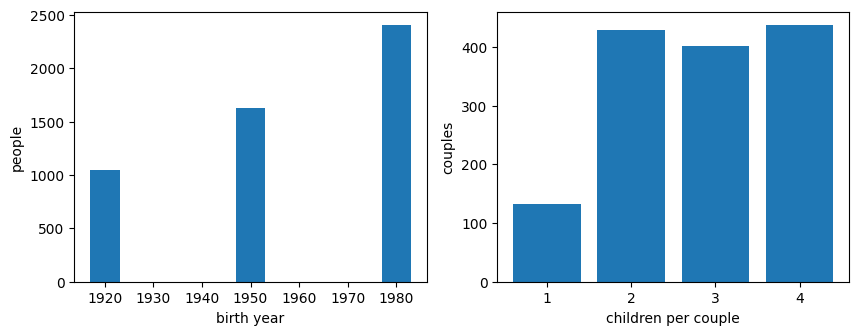

born per year: {1920: 1044, 1950: 1626, 1980: 2405}
couples by number of children: {1: 133, 2: 429, 3: 401, 4: 437}


In [3]:
years, n_born = np.unique(reg.birth_time, return_counts=True)    # people born in each year
couples = Counter((f, m) for f, m in zip(reg.father, reg.mother) if f in row and m in row)
sizes, n_couples = np.unique(list(couples.values()), return_counts=True)   # children per couple

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
ax1.bar(years, n_born, width=6)       # how many people were born in each year
ax1.set_xlabel("birth year")
ax1.set_ylabel("people")
ax2.bar(sizes, n_couples)             # how many couples have each number of children
ax2.set_xlabel("children per couple")
ax2.set_ylabel("couples")
plt.show()
print("born per year:", dict(zip(years.astype(int).tolist(), n_born.tolist())))
print("couples by number of children:", dict(zip(sizes.tolist(), n_couples.tolist())))

**Answer.** There are three generations, born in 1920, 1950 and 1980 (1,044, 1,626 and
2,405 people; the 1950 group includes spouses who married into the families). Couples
have one to four children, most of them two to four. Most people therefore have parents
and siblings in the register.

### Q2: Run the cell. At what ages are people diagnosed? Are men diagnosed more often, earlier, or both?

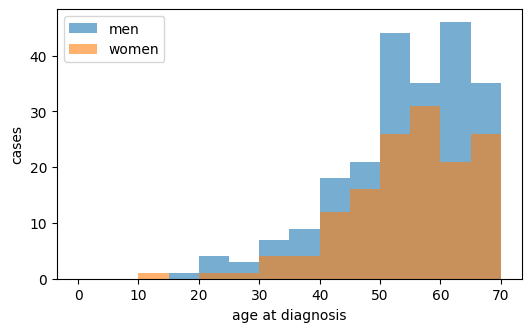

cases: 223 men, 143 women; median age at diagnosis 56 and 56


In [4]:
bins = np.arange(0, 75, 5)                                      # 5-year age bins
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(reg.onset[male & reg.status], bins=bins, alpha=0.6, label="men")
ax.hist(reg.onset[~male & reg.status], bins=bins, alpha=0.6, label="women")   # the women's ages at diagnosis
ax.set_xlabel("age at diagnosis")
ax.set_ylabel("cases")
ax.legend()
plt.show()
print(f"cases: {(male & reg.status).sum()} men, {(~male & reg.status).sum()} women; median age at "
      f"diagnosis {np.median(reg.onset[male & reg.status]):.0f} and {np.median(reg.onset[~male & reg.status]):.0f}")

**Answer.** 223 men and 143 women are diagnosed, nine in ten between 40 and 70. Men are
diagnosed more often. The median age at diagnosis is 56 in both sexes, so this sample shows
no clear difference in timing, although the true curves put men's diagnoses slightly earlier.

### Q3: Plot the Kaplan–Meier survival and the cumulative incidence by sex.

The survival curve S(t) is the share still undiagnosed at age t; the cumulative incidence
is 1 − S(t). `kaplan_meier_cip(entry, exit, event)` estimates the cumulative incidence. Everyone enters at
birth and leaves at diagnosis or at 70. Fill in the exit ages and events. Do the observed
curves follow the true ones (dashed)? Why should men and women not share one curve?

men: 2.5% diagnosed by 50, 9.0% by 70
women: 1.5% diagnosed by 50, 5.5% by 70


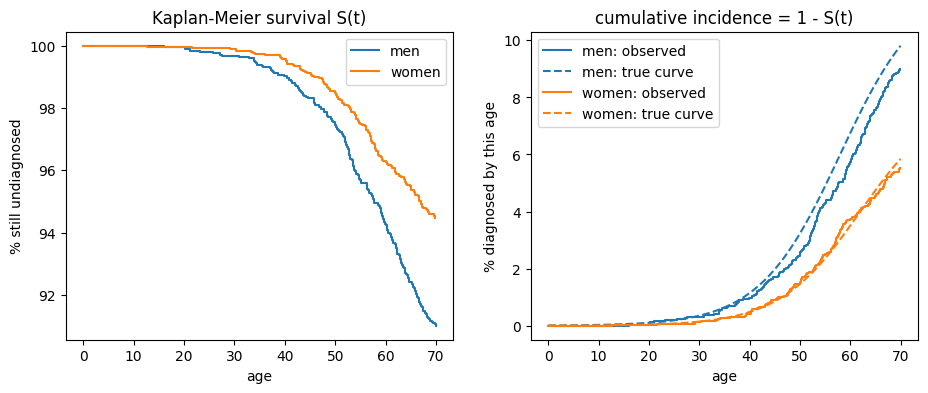

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for label, keep, cip, colour in (("men", male, CIP_M, "C0"), ("women", ~male, CIP_F, "C1")):
    # Kaplan-Meier: everyone enters at birth and leaves at diagnosis or at 70
    km = kaplan_meier_cip(np.zeros(keep.sum()), reg.age[keep], reg.status[keep])
    print(f"{label}: {km.values[km.ages <= 50][-1]:.1%} diagnosed by 50, {km.values[-1]:.1%} by 70")
    ages, inc = np.r_[0, km.ages], np.r_[0, km.values]      # start both curves at age 0
    ax1.step(ages, 100 * (1 - inc), where="post", color=colour, label=label)   # survival S(t)
    ax2.step(ages, 100 * inc, where="post", color=colour, label=f"{label}: observed")
    ax2.plot(AGES[:71], 100 * cip[:71], ls="--", color=colour, label=f"{label}: true curve")
ax1.set_title("Kaplan-Meier survival S(t)")
ax1.set_ylabel("% still undiagnosed")
ax2.set_title("cumulative incidence = 1 - S(t)")
ax2.set_ylabel("% diagnosed by this age")
for ax in (ax1, ax2):
    ax.set_xlabel("age")
    ax.legend()
plt.show()

**Answer.** By 70, 9.0% of men and 5.5% of women are diagnosed (true values 9.8% and 5.8%;
the gap is sampling noise). Because the sexes differ, LT-FH++ is given one incidence curve
per sex. With complete follow-up, as here, Kaplan–Meier equals the plain share diagnosed;
it matters when follow-up ends early. If people can die before diagnosis, the
Aalen–Johansen estimator (`aalen_johansen_cip`) should be used instead.

### Q4: Run the cell. How much more often are people with a diagnosed parent diagnosed themselves? Why does that matter for this exercise?

a diagnosed parent: n = 578, 14.4% diagnosed by 70
no diagnosed parent: n = 3364, 5.9% diagnosed by 70


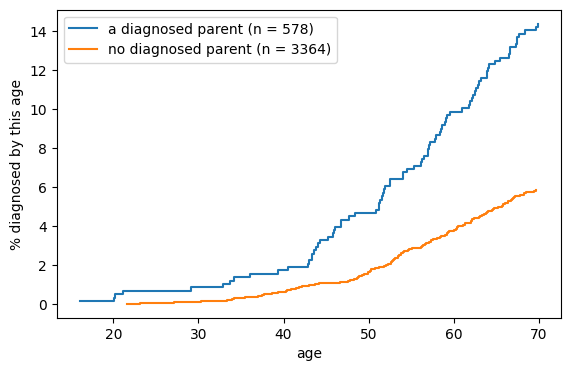

In [6]:
has_parents = np.array([f in row for f in reg.father])       # parents recorded in the register
parent_dx = np.array([any(reg.status[row[p]] for p in (f, m) if p in row)
                      for f, m in zip(reg.father, reg.mother)])   # a parent diagnosed by 70

fig, ax = plt.subplots(figsize=(6.5, 4))
for label, keep in (("a diagnosed parent", parent_dx),
                    ("no diagnosed parent", has_parents & ~parent_dx)):   # parents recorded, neither diagnosed
    km = kaplan_meier_cip(np.zeros(keep.sum()), reg.age[keep], reg.status[keep])
    ax.step(km.ages, 100 * km.values, where="post", label=f"{label} (n = {keep.sum()})")
    print(f"{label}: n = {keep.sum()}, {km.values[-1]:.1%} diagnosed by 70")
ax.set_xlabel("age")
ax.set_ylabel("% diagnosed by this age")
ax.legend()
plt.show()

**Answer.** 14.4% of the people with a diagnosed parent are diagnosed by 70, against 5.9%
of those whose recorded parents were not: 2.4 times as often. This familial aggregation is
what LT-FH++ uses. In real data, shared environment could also cause it.

### Q5: Run the cell. How different is the true `g` of cases and non-cases? Does a high `g` mean a person will be diagnosed?

This can only be plotted in a simulation.

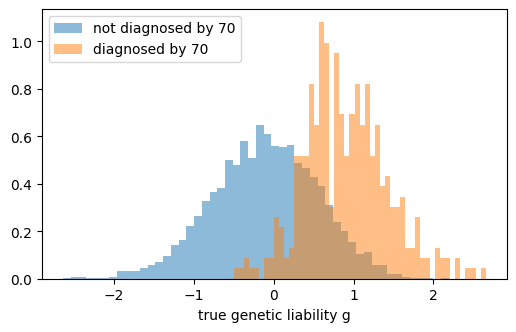

mean g: cases 0.91, non-cases -0.11; of the people with g > 1, 43% were diagnosed


In [7]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(g[~reg.status], bins=50, density=True, alpha=0.5, label="not diagnosed by 70")
ax.hist(g[reg.status], bins=50, density=True, alpha=0.5, label="diagnosed by 70")    # g of the cases
ax.set_xlabel("true genetic liability g")
ax.legend()
plt.show()
print(f"mean g: cases {g[reg.status].mean():.2f}, non-cases {g[~reg.status].mean():.2f}; "
      f"of the people with g > 1, {reg.status[g > 1].mean():.0%} were diagnosed")

**Answer.** Cases average 0.91 and non-cases −0.11, but a high `g` does not guarantee the
disease: only 43% of the people with `g` above 1 are diagnosed by 70.

### Scoring

`estimate_liabilities` returns each person's score (`.est`), the expected `g` given the
family's records, and its posterior variance (`.var`), the uncertainty left about that
person's `g`. Neither is a probability of disease. `strata=sex` gives each sex its own
incidence curve. There are two kinds of score:
- `use="gwas"`: all records up to age 70, including the person's own diagnosis.
- `use="prediction"`: only records made before the person's 40th birthday, and not their
  own status. The cutoff is a date, so a parent may be 70 then and a sibling 38.

The helpers below compute the second kind (`score_at_40`) and rescore everyone under
another h² (`score`, used in Part E).

In [8]:
curves = {"M": (AGES, CIP_M, 0.12), "F": (AGES, CIP_F, 0.08)}   # sex -> (ages, curve, lifetime K)

scores = estimate_liabilities(
    reg.ids, reg.father, reg.mother,          # the pedigree: who is whose parent
    probands=reg.ids,                         # whom to score: everyone
    status=reg.status, age=reg.age,           # diagnosed by 70? age at diagnosis or at 70
    strata=sex, cip_by_stratum=curves,        # each sex has its own incidence curve, so its own thresholds
    h2=H2,                                    # heritability: you supply it, the scorer never estimates it
    use="gwas")                               # also use each person's own diagnosis

est, var = scores.est, scores.var
print(f"corr(score, g) = {corr(est, g):.3f}")
print(f"var(score) = {est.var():.3f}  +  mean posterior variance = {var.mean():.3f}"
      f"  =  {est.var() + var.mean():.3f}")

corr(score, g) = 0.529
var(score) = 0.128  +  mean posterior variance = 0.359  =  0.488


In [9]:
free40 = reg.onset > 40                     # still undiagnosed on their 40th birthday


def score(h2):
    """Everyone's score from all records up to 70 (use="gwas"): (mean, variance)."""
    s = estimate_liabilities(reg.ids, reg.father, reg.mother, probands=reg.ids,
                             status=reg.status, age=reg.age, strata=sex, cip_by_stratum=curves,
                             h2=h2, use="gwas")
    return s.est, s.var


def score_at_40(h2):
    """Scores as known on each person's 40th birthday (use="prediction"), for the
    people still undiagnosed then: their own status and every later record are hidden."""
    s = estimate_liabilities(reg.ids, reg.father, reg.mother,
                             probands=[p for p, keep in zip(reg.ids, free40) if keep],
                             status=reg.status, age=reg.age, strata=sex, cip_by_stratum=curves,
                             h2=h2, use="prediction",
                             birth_time=reg.birth_time,                  # everyone's birth date
                             index_time=(reg.birth_time + 40)[free40])   # each proband's 40th birthday
    return s.est, s.var


est40, var40 = score_at_40(H2)
print(f"{free40.sum()} people undiagnosed at 40; corr(score at 40, g) = {corr(est40, g[free40]):.3f}")

5040 people undiagnosed at 40; corr(score at 40, g) = 0.280


### Q6: Plot the score against the true `g` (fill in the two arrays). How well does the score track `g`?

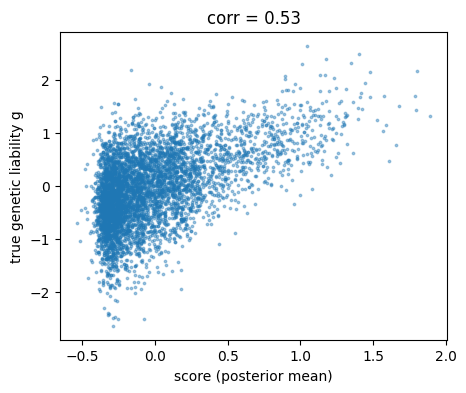

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(est, g, s=3, alpha=0.4)             # x: the score est, y: the truth g
ax.set_xlabel("score (posterior mean)")
ax.set_ylabel("true genetic liability g")
ax.set_title(f"corr = {corr(est, g):.2f}")
plt.show()

**Answer.** The correlation is 0.53: high scores go with high `g`, but the spread at any
score is large. Most people have no diagnosed relatives and get small negative scores.

## Part A: What the score uses

A yes/no family history only says whether a relative was diagnosed. The score also uses
which relatives were diagnosed, how many, and at what age.

### Q7: Compare the scores of people with different family histories.

The plots show people undiagnosed at 70 whose parents are both in the register. Before
running the cell, guess: who gets the higher score, someone whose parent was diagnosed at
45 or someone whose parent was diagnosed at 68? Explain the plots with the age-dependent
thresholds from the slides.

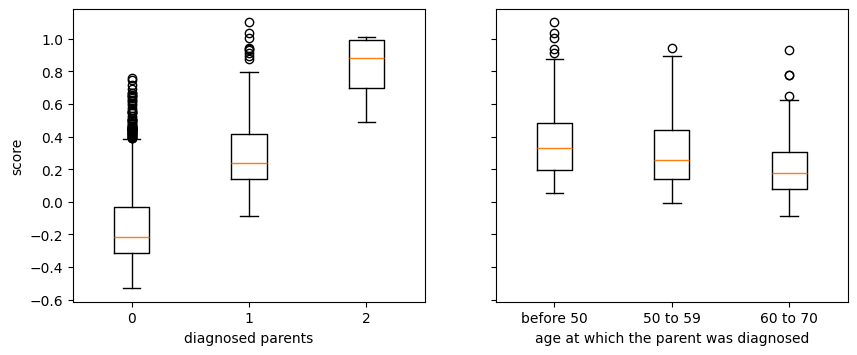

0 diagnosed parents: n = 3167, mean score -0.15
1 diagnosed parents: n = 485, mean score 0.29
2 diagnosed parents: n = 10, mean score 0.82
parent diagnosed before 50: n = 127, mean score 0.37
parent diagnosed 50 to 59: n = 191, mean score 0.30
parent diagnosed 60 to 70: n = 167, mean score 0.21


In [11]:
# people undiagnosed at 70 with both parents in the register
undiagnosed = ~reg.status & has_parents
n_dx = np.array([sum(reg.status[row[p]] for p in (f, m) if p in row)
                 for f, m in zip(reg.father, reg.mother)])            # diagnosed parents: 0, 1 or 2
parent_onset = np.array([min([reg.onset[row[p]] for p in (f, m) if p in row and reg.status[row[p]]], default=np.nan)
                         for f, m in zip(reg.father, reg.mother)])    # age of the (first) diagnosed parent
one = undiagnosed & (n_dx == 1)                                      # exactly one diagnosed parent

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
ax1.boxplot([est[undiagnosed & (n_dx == k)] for k in (0, 1, 2)])     # the scores of the people in `undiagnosed` with k diagnosed parents
ax1.set_xticks([1, 2, 3], ["0", "1", "2"])
ax1.set_xlabel("diagnosed parents")
ax1.set_ylabel("score")
ax2.boxplot([est[one & (parent_onset < 50)], est[one & (parent_onset >= 50) & (parent_onset < 60)],
             est[one & (parent_onset >= 60)]])
ax2.set_xticks([1, 2, 3], ["before 50", "50 to 59", "60 to 70"])
ax2.set_xlabel("age at which the parent was diagnosed")
plt.show()
for k in (0, 1, 2):
    print(f"{k} diagnosed parents: n = {(undiagnosed & (n_dx == k)).sum()}, mean score {est[undiagnosed & (n_dx == k)].mean():.2f}")
for label, lo, hi in (("before 50", 0, 50), ("50 to 59", 50, 60), ("60 to 70", 60, 71)):
    sel = one & (parent_onset >= lo) & (parent_onset < hi)
    print(f"parent diagnosed {label}: n = {sel.sum()}, mean score {est[sel].mean():.2f}")

**Answer.** The mean score is −0.15 with no diagnosed parent, 0.29 with one and 0.82 with
two (only 10 people). With one diagnosed parent it is 0.37 if the parent was diagnosed
before 50, 0.30 at 50–59 and 0.21 at 60–70. Few people are diagnosed young, so the
threshold is high at young ages, and a parent diagnosed early must have a high liability.
Part of that liability is genetic, and a child's expected `g` is the average of the
parents' `g`, so the child's score rises. The boxes overlap because siblings, grandparents
and the person's own sex also enter the score.

## Part B: Predicting later diagnosis

![Liability thresholds at ages 40 and 70.](https://bvilhjal.github.io/ATIG_2026/teaching_days/2026-09-24/LTFH/figures/thresholds.png)

We now use the score at 40 (`est40`) for the people undiagnosed at 40, and ask who is
diagnosed between 40 and 70.

In [12]:
y = reg.status[free40]      # diagnosed between 40 and 70, one entry per person in est40
print(f"{y.sum()} of {len(y)} people undiagnosed at 40 were diagnosed by 70")

331 of 5040 people undiagnosed at 40 were diagnosed by 70


### Q8: Run the cell. How much do the scores of later cases and non-cases overlap?

The AUC is the chance that a random later case scores above a random non-case. The cell
prints it for the score at 40, for the true `g`, and for the `use="gwas"` score, which saw
each person's own diagnosis. Why is the AUC of the true `g` below 1? Why is the
`use="gwas"` score almost perfect, and why is that not prediction?

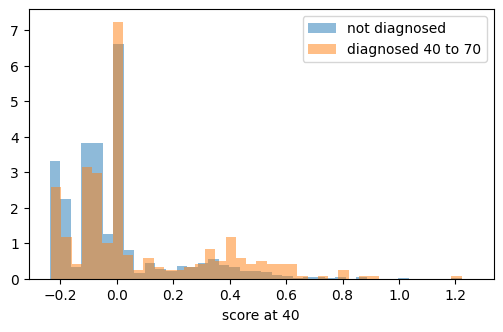

AUC score at 40        0.595
AUC true g             0.880
AUC use='gwas' score   0.994


In [13]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(est40[~y], bins=40, density=True, alpha=0.5, label="not diagnosed")
ax.hist(est40[y], bins=40, density=True, alpha=0.5, label="diagnosed 40 to 70")   # the cases' scores
ax.set_xlabel("score at 40")
ax.legend()
plt.show()

print(f"AUC score at 40        {auc(est40, y):.3f}")
print(f"AUC true g             {auc(g[free40], y):.3f}")
print(f"AUC use='gwas' score   {auc(est[free40], y):.3f}")

**Answer.** The histograms overlap heavily. The AUCs are 0.60 for the score at 40, 0.88
for the true `g` (below 1 because the environmental part of liability is unknown) and 0.99
for the `use="gwas"` score. That score contains the outcome, so its AUC is leakage, not
prediction.

### Q9: Convert the score into a risk and compare it with what happened.

A score ranks people; a risk is a probability. Given the relatives, a person's liability
is roughly normal with mean `est40` and variance `var40 + 1 - H2` (genetic uncertainty plus
environment). The risk of diagnosis between 40 and 70 is the chance that it lies above the
threshold at 70 but below the one at 40, divided by the chance of being undiagnosed at 40.

Run the cell. How close are predicted and observed risks in each fifth of the score? How
much do the lowest and highest fifths differ?

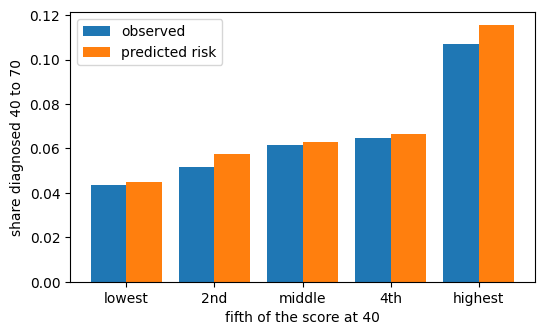

mean predicted risk 0.069   observed 0.066
  lowest fifth: observed 0.044, predicted 0.045
     2nd fifth: observed 0.052, predicted 0.057
  middle fifth: observed 0.062, predicted 0.063
     4th fifth: observed 0.064, predicted 0.067
 highest fifth: observed 0.107, predicted 0.116


In [14]:
cip40 = np.where(male, np.interp(40, AGES, CIP_M), np.interp(40, AGES, CIP_F))[free40]
cip70 = np.where(male, np.interp(70, AGES, CIP_M), np.interp(70, AGES, CIP_F))[free40]
T40, T70 = norm.isf(cip40), norm.isf(cip70)            # each person's LT-FH++ thresholds at 40 and 70


def risk_40_to_70(mean_g, var_g, h2):
    """Normal approximation to P(diagnosed 40–70 | relatives, undiagnosed at 40)."""
    sd = np.sqrt(var_g + 1 - h2)          # genetic uncertainty + environmental variance
    below40 = norm.cdf((T40 - mean_g) / sd)
    below70 = norm.cdf((T70 - mean_g) / sd)
    return (below40 - below70) / below40  # condition on being undiagnosed at 40


risk = risk_40_to_70(est40, var40, H2)

fifths = np.array_split(np.argsort(est40, kind="stable"), 5)   # lowest to highest score
observed = [y[idx].mean() for idx in fifths]                   # share diagnosed in each fifth
predicted = [risk[idx].mean() for idx in fifths]               # mean risk in each fifth

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(np.arange(5) - 0.2, observed, width=0.4, label="observed")
ax.bar(np.arange(5) + 0.2, predicted, width=0.4, label="predicted risk")
ax.set_xticks(range(5), ["lowest", "2nd", "middle", "4th", "highest"])
ax.set_xlabel("fifth of the score at 40")
ax.set_ylabel("share diagnosed 40 to 70")
ax.legend()
plt.show()
print(f"mean predicted risk {risk.mean():.3f}   observed {y.mean():.3f}")
for name, o, p in zip(("lowest", "2nd", "middle", "4th", "highest"), observed, predicted):
    print(f"{name:>8} fifth: observed {o:.3f}, predicted {p:.3f}")

**Answer.** The mean predicted risk is 6.9% against 6.6% observed: 4.5% against 4.4% in
the lowest fifth and 11.6% against 10.7% in the highest. Risk is 2.4 times higher in the
highest fifth, yet most people there are not diagnosed. Good agreement is expected here,
because the calculation uses the true incidence curves and h². The AUC measures ranking;
calibration asks whether predicted risks match observed rates.

## Part C: The score against a simple family history (homework)

The next cell finds each person's parents and siblings and marks who has a diagnosed one,
by age 70 (`fh`) and by their own 40th birthday (`fh40`).

In [15]:
children = {}                                        # (father, mother) -> rows of their children
for i, (f, m) in enumerate(zip(reg.father, reg.mother)):
    if f in row and m in row:
        children.setdefault((f, m), []).append(i)


def first_degree(i):
    """Rows of person i's parents and full siblings."""
    f, m = reg.father[i], reg.mother[i]
    parents = [row[p] for p in (f, m) if p in row]
    siblings = [j for j in children.get((f, m), []) if j != i]
    return np.array(parents + siblings, dtype=int)


fdr = [first_degree(i) for i in range(len(reg.ids))]
diag_time = reg.birth_time + reg.onset               # calendar time of each diagnosis
birth40 = reg.birth_time + 40                        # calendar time of each 40th birthday

# yes/no family history: any affected parent or sibling, by 70 and by one's own 40th birthday
fh = np.array([reg.status[r].any() for r in fdr])
fh40 = np.array([(reg.status[r] & (diag_time[r] <= birth40[i])).any() for i, r in enumerate(fdr)])
print(f"family-history positive: {fh.sum()} by age 70, {fh40.sum()} at their 40th birthday")

family-history positive: 971 by age 70, 627 at their 40th birthday


### Q10: How much of `g` do own status, family history and the score explain? Fill in R², then explain why the score does best.

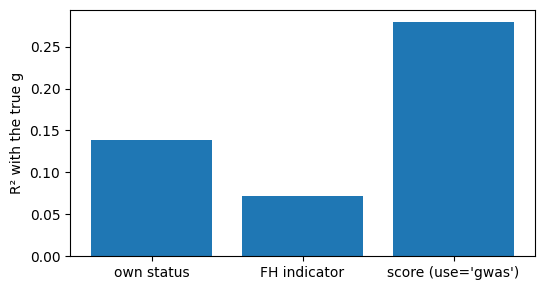

prediction at 40: AUC FH indicator 0.559, AUC score 0.595
R2: own status 0.139, FH indicator 0.072, score (use='gwas') 0.280


In [16]:
names = ["own status", "FH indicator", "score (use='gwas')"]
r2 = [corr(x, g) ** 2 for x in (reg.status, fh, est)]      # R²: the squared correlation of each with g

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar(names, r2)
ax.set_ylabel("R² with the true g")
plt.show()
print(f"prediction at 40: AUC FH indicator {auc(fh40[free40], y):.3f}, AUC score {auc(est40, y):.3f}")
print("R2:", ", ".join(f"{n} {v:.3f}" for n, v in zip(names, r2)))

**Answer.** R² is 0.14 for own status, 0.07 for family history and 0.28 for the score. The
score combines own status, ages, sex-specific thresholds and more relatives; the indicator
only says whether a parent or sibling was diagnosed. For predicting diagnosis after 40 the
AUC is 0.56 for family history and 0.60 for the score. Own status is left out there because
nobody in that group was diagnosed at 40.

## Part D: Heritability from parents and children (homework)

The tetrachoric correlation ρ is the correlation of two unobserved normal liabilities,
estimated from a 2×2 table of two yes/no outcomes. With additive genes, random mating and
no shared environment, parent and child liabilities correlate h²/2, so h² ≈ 2ρ. The next
cell lists all parent–child pairs.

In [17]:
from ltpred import tetrachoric

# every parent-child pair in the register, as row numbers
pairs = [(row[p], i) for i, (f, m) in enumerate(zip(reg.father, reg.mother))
         for p in (f, m) if p in row]
par, kid = np.array(pairs).T


def table(a, b):
    """2x2 table of two True/False arrays: both, first only, second only, neither."""
    return np.array([(a & b).sum(), (a & ~b).sum(), (~a & b).sum(), (~a & ~b).sum()])

### Q11: Estimate h² from the parent–child pairs.

Is it close to 0.5? The standard error treats all pairs as independent: why is that too
optimistic?

In [18]:
p_status, k_status = reg.status[par], reg.status[kid]
t = tetrachoric(p_status, k_status)
print(f"{len(par)} pairs, table {table(p_status, k_status)}")
print(f"h2 = 2 rho = {2 * t.rho:.2f} +/- {2 * t.se:.2f} (pairs treated as independent)   truth {H2}")

7884 pairs, table [  88  505  472 6819]
h2 = 2 rho = 0.48 +/- 0.07 (pairs treated as independent)   truth 0.5


**Answer.** h² = 0.48 from 7,884 pairs, close to 0.5. The standard error of 0.07 treats
the pairs as independent, but each parent appears once per child and families overlap, so
the real uncertainty is larger. Resampling whole families would account for that.

### Q12: What would make this estimate wrong in a real register?

Think about follow-up, sex, shared environment, mating and sampling.

**Answer.** The method assumes one threshold for all parents and one for all children, but
people differ in sex and follow-up time (Q3 showed a sex difference here). Shared
environment can mimic genetic similarity, assortative mating changes the h²/2 relationship,
and sampling families because of the disease biases the estimate unless the sampling is
modelled.

## Part E: Observed and liability scale (homework)

![A liability split into a 0/1 outcome.](https://bvilhjal.github.io/ATIG_2026/teaching_days/2026-09-24/LTFH/figures/observed_scale.png)

For a yes/no trait, h² on the observed 0/1 scale depends on the case fraction in the
sample. Some GWAS software reports this scale and some converts to the liability scale:
check which ([Lee et al. 2011](https://doi.org/10.1016/j.ajhg.2011.02.002)). The cell uses
a simplified disease with one lifetime threshold, `K = 0.10` and liability-scale `H2 = 0.5`.

### Q13: Run the cell. How does the observed-scale h² depend on the case fraction `P`?

The cell then scores everyone with the population-sample value, passed to the scorer as if
it were a liability-scale h². What happens to the correlation with `g`, the slope, the AUC
at 40 and the risks in the lowest and highest fifths? Does a similar AUC mean similar risks?

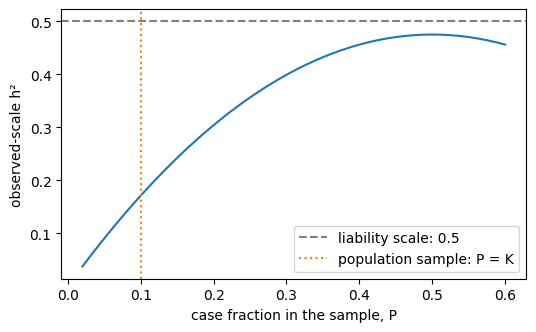

population sample 0.171, 1:1 study 0.475


corr(score, g) 0.529 -> 0.519; slope of g on score 1.04 -> 2.37


AUC at 40 0.595 -> 0.596
lowest fifth: risk 0.045 -> 0.060, observed 0.044
highest fifth: risk 0.116 -> 0.087, observed 0.107


In [19]:
from ltpred import liability_to_observed_h2

Ps = np.linspace(0.02, 0.6, 50)                # case fraction in the sample
h2_obs = [float(liability_to_observed_h2(H2, K, P)) for P in Ps]   # observed-scale h² for each P

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(Ps, h2_obs)
ax.axhline(H2, ls="--", color="grey", label="liability scale: 0.5")
ax.axvline(K, ls=":", color="C1", label="population sample: P = K")
ax.set_xlabel("case fraction in the sample, P")
ax.set_ylabel("observed-scale h²")
ax.legend()
plt.show()
print(f"population sample {float(liability_to_observed_h2(H2, K, None)):.3f}, "
      f"1:1 study {float(liability_to_observed_h2(H2, K, 0.5)):.3f}")

h2_wrong = float(liability_to_observed_h2(H2, K, None))   # observed-scale value, used as if liability-scale
est_wrong = score(h2_wrong)[0]
print(f"corr(score, g) {corr(est, g):.3f} -> {corr(est_wrong, g):.3f}; "
      f"slope of g on score {np.polyfit(est, g, 1)[0]:.2f} -> {np.polyfit(est_wrong, g, 1)[0]:.2f}")
est40_wrong, var40_wrong = score_at_40(h2_wrong)
risk_wrong = risk_40_to_70(est40_wrong, var40_wrong, h2_wrong)
print(f"AUC at 40 {auc(est40, y):.3f} -> {auc(est40_wrong, y):.3f}")
for label, idx in (("lowest", fifths[0]), ("highest", fifths[-1])):     # the same people as in Q9
    print(f"{label} fifth: risk {risk[idx].mean():.3f} -> {risk_wrong[idx].mean():.3f}, observed {y[idx].mean():.3f}")

**Answer.** The observed-scale h² is 0.17 in a population sample (P = K) and 0.48 in a
balanced case–control study; the liability-scale value stays 0.5. Scoring with 0.17 barely
changes the correlation with `g` (0.53 to 0.52) or the AUC at 40 (0.595 to 0.596), but the
slope of `g` on the score rises from 1.04 to 2.37: the scores are squeezed together. So are
the risks: 6.0% and 8.7% in the lowest and highest fifths, against 4.5% and 11.6% with the
right h² (4.4% and 10.7% observed). Nothing warns you: the scorer cannot tell that h² was
on the wrong scale.

### Q14: Summarise

In about 100 words, say what the score estimates, what you found, and what it cannot
tell you.

**Answer (example).** The score is the expected genetic liability given a family's
diagnoses and ages, the incidence curves and h². It correlated 0.53 with the true `g` and
was higher with more, and earlier, parental diagnoses. Scored at 40 it predicted diagnosis
by 70 with an AUC of 0.60, against 0.56 for a yes/no family history, and its risks matched
the observed rates. Parent–child pairs gave h² = 0.48. An observed-scale h² passed to the
scorer kept the ranking but distorted the risks. The score is not a risk and cannot
estimate its own h².

## Environment

In [20]:
import platform, scipy
print(f"Python {platform.python_version()}, NumPy {np.__version__}, "
      f"SciPy {scipy.__version__}, ltpred {ltpred.__version__}")

Python 3.10.20, NumPy 1.26.4, SciPy 1.15.3, ltpred 0.7.2
